# Prepare environment

In [1]:
import json
import datetime
from pathlib import Path
from matplotlib import pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm

from phong_dataset import PhongDataset
from unet import UNet
from ddpm import DDPM
from evaluate import compute_metrics
from config import DATA_DIR, DIFFUSION_MODEL_RESULTS

In [2]:
DIFFUSION_MODEL_RESULTS.mkdir(parents=True, exist_ok=True)

In [3]:
FULL_DATASET_SIZE = 3000
TESTING_DATASET_SIZE = 600
VALIDATION_DATASET_SIZE = int((FULL_DATASET_SIZE - TESTING_DATASET_SIZE) * 0.15)
TRAINING_DATASET_SIZE = FULL_DATASET_SIZE - VALIDATION_DATASET_SIZE - TESTING_DATASET_SIZE

PARAMS_DIM = 10
IMAGE_SIZE = 128

BATCH_SIZE = 16

UNET_BASE_CHANNELS_NUM = 64
DIFFUSION_STEPS_NUM = 200

EPOCHS = 50
LEARNING_RATE = 1e-4
VAL_METRIC_SAMPLES = 32
EARLY_STOPPING_PATIENCE = 3

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [5]:
def get_timestamp() -> str:
    ct = datetime.datetime.now()

    return ct.strftime("%Y-%m-%d_%H-%M-%S")

In [6]:
CURRENT_TIMESTAMP = get_timestamp()

CURRENT_RUN_DIRECTORY = Path(f"{DIFFUSION_MODEL_RESULTS}/{CURRENT_TIMESTAMP}")
CURRENT_RUN_DIRECTORY.mkdir(parents=True, exist_ok=True)

# Load dataset

In [7]:
train_ids = list(range(0, TRAINING_DATASET_SIZE))
val_ids = list(range(TRAINING_DATASET_SIZE, FULL_DATASET_SIZE - TESTING_DATASET_SIZE))
test_ids = list(range(FULL_DATASET_SIZE - TESTING_DATASET_SIZE, FULL_DATASET_SIZE))

print(f"Training dataset size: {len(train_ids)}")
print(f"Validation dataset size: {len(val_ids)}")
print(f"Testing dataset size: {len(test_ids)}")

Training dataset size: 2040
Validation dataset size: 360
Testing dataset size: 600


In [8]:
print(f"Training dataset range: {min(train_ids)} - {max(train_ids)}")
print(f"Validation dataset range: {min(val_ids)} - {max(val_ids)}")
print(f"Testing dataset range: {min(test_ids)} - {max(test_ids)}")

Training dataset range: 0 - 2039
Validation dataset range: 2040 - 2399
Testing dataset range: 2400 - 2999


In [9]:
train_dataset = PhongDataset(DATA_DIR, train_ids)
val_dataset = PhongDataset(DATA_DIR, val_ids)
test_dataset = PhongDataset(DATA_DIR, test_ids)

In [10]:
print(f"Sample training data shape: {train_dataset[0][0].shape} (params), {train_dataset[0][1].shape} (image)")
print(f"Sample validation data shape: {val_dataset[0][0].shape} (params), {val_dataset[0][1].shape} (image)")
print(f"Sample testing data shape: {test_dataset[0][0].shape} (params), {test_dataset[0][1].shape} (image)")

Sample training data shape: torch.Size([10]) (params), torch.Size([3, 128, 128]) (image)
Sample validation data shape: torch.Size([10]) (params), torch.Size([3, 128, 128]) (image)
Sample testing data shape: torch.Size([10]) (params), torch.Size([3, 128, 128]) (image)


In [11]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

Number of training batches: 128
Number of validation batches: 23
Number of testing batches: 38


# Load model

In [13]:
model = UNet(param_dim=PARAMS_DIM, base_ch=UNET_BASE_CHANNELS_NUM).to(device)
ddpm = DDPM(T=DIFFUSION_STEPS_NUM, device=device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params}")

Model parameters: 4170307


# Training

In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, EPOCHS)

In [15]:
history: dict[str, list[float]] = {
    "train_loss": [],
    "val_loss": [],
    "train_lpips": [],
    "val_lpips": [],
    "train_ssim": [],
    "val_ssim": [],
    "train_hausdorff": [],
    "val_hausdorff": [],
    "lr": [],
}

best_val_loss = float("inf")
early_stopping_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for params, images in tqdm(train_loader, desc=f"Epoch {epoch+1} / {EPOCHS}", leave=False):
        params, images = params.to(device), images.to(device)

        t = torch.randint(0, ddpm.T, (images.size(0),), device=device)

        noisy, noise = ddpm.q_sample(images, t)

        pred = model(noisy, t, params)
        loss = F.mse_loss(pred, noise)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for params, images in tqdm(val_loader, desc=f"Val loss {epoch+1} / {EPOCHS}", leave=False):
            params, images = params.to(device), images.to(device)

            t = torch.randint(0, ddpm.T, (images.size(0),), device=device)

            noisy, noise = ddpm.q_sample(images, t)

            pred = model(noisy, t, params)
            val_loss += F.mse_loss(pred, noise).item()

    val_loss /= len(val_loader)

    train_metrics = compute_metrics(model, ddpm, train_loader, device, num_samples=VAL_METRIC_SAMPLES)
    val_metrics = compute_metrics(model, ddpm, val_loader, device, num_samples=VAL_METRIC_SAMPLES)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ssim"].append(train_metrics["SSIM"])
    history["train_lpips"].append(train_metrics["LPIPS"])
    history["train_hausdorff"].append(train_metrics["Hausdorff"])
    history["val_ssim"].append(val_metrics["SSIM"])
    history["val_lpips"].append(val_metrics["LPIPS"])
    history["val_hausdorff"].append(val_metrics["Hausdorff"])
    history["lr"].append(scheduler.get_last_lr()[0])

    print(
        f"Epoch {epoch+1} / {EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train SSIM: {train_metrics['SSIM']:.4f} | Val SSIM: {val_metrics['SSIM']:.4f} | "
        f"Train LPIPS: {train_metrics['LPIPS']:.4f} | Val LPIPS: {val_metrics['LPIPS']:.4f} | "
        f"Train Hausdorff: {train_metrics['Hausdorff']:.2f} | Val Hausdorff: {val_metrics['Hausdorff']:.2f} | "
        f"lr: {scheduler.get_last_lr()[0]:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stopping_counter = 0

        torch.save(model.state_dict(), CURRENT_RUN_DIRECTORY / "best_model.pth")
        print("Best model saved.")
    else:
        early_stopping_counter += 1
        print(f"No improvement for {early_stopping_counter} / {EARLY_STOPPING_PATIENCE} epochs.")

        if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

print(f"Training finished with best val loss: {best_val_loss:.4f}")

/home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project3-rendering/venv/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project3-rendering/venv/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project3-rendering/venv/lib/python3.14/site-packages/lpips/weights/v0.1/alex.pth


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project3-rendering/venv/lib/python3.14/site-packages/lpips/weights/v0.1/alex.pth


Epoch 1 / 50 | Train Loss: 0.1484 | Val Loss: 0.0358 | Train SSIM: 0.0022 | Val SSIM: 0.0018 | Train LPIPS: 0.7985 | Val LPIPS: 0.8011 | Train Hausdorff: 130.10 | Val Hausdorff: 129.70 | lr: 0.000100
Best model saved.


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project3-rendering/venv/lib/python3.14/site-packages/lpips/weights/v0.1/alex.pth


...

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project3-rendering/venv/lib/python3.14/site-packages/lpips/weights/v0.1/alex.pth


Epoch 13 / 50 | Train Loss: 0.0049 | Val Loss: 0.0056 | Train SSIM: 0.0124 | Val SSIM: 0.0098 | Train LPIPS: 0.3776 | Val LPIPS: 0.3576 | Train Hausdorff: 76.38 | Val Hausdorff: 64.97 | lr: 0.000084
No improvement for 2 / 3 epochs.


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project3-rendering/venv/lib/python3.14/site-packages/lpips/weights/v0.1/alex.pth


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project3-rendering/venv/lib/python3.14/site-packages/lpips/weights/v0.1/alex.pth


Epoch 14 / 50 | Train Loss: 0.0042 | Val Loss: 0.0051 | Train SSIM: 0.0080 | Val SSIM: 0.0075 | Train LPIPS: 0.5033 | Val LPIPS: 0.5012 | Train Hausdorff: 93.81 | Val Hausdorff: 92.98 | lr: 0.000082
No improvement for 3 / 3 epochs.
Early stopping triggered at epoch 14.
Training finished with best val loss: 0.0043


In [16]:
history_path = Path(f"{CURRENT_RUN_DIRECTORY}/history.json")

with open(history_path, "w") as f:
    json.dump(history, f, indent=4, sort_keys=True)

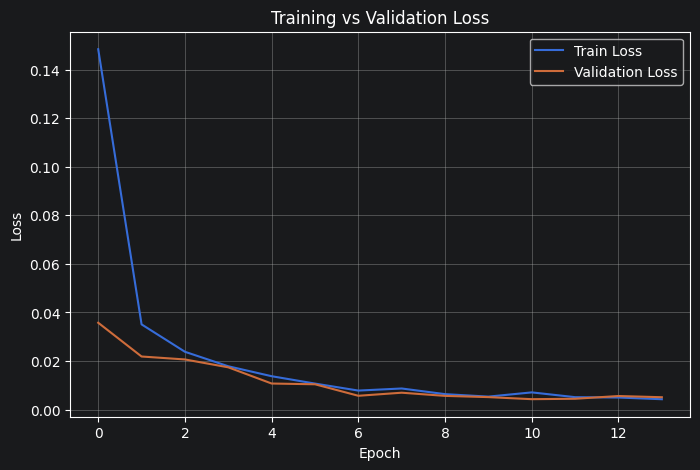

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(f"{CURRENT_RUN_DIRECTORY}/loss.png", dpi=300, bbox_inches="tight")

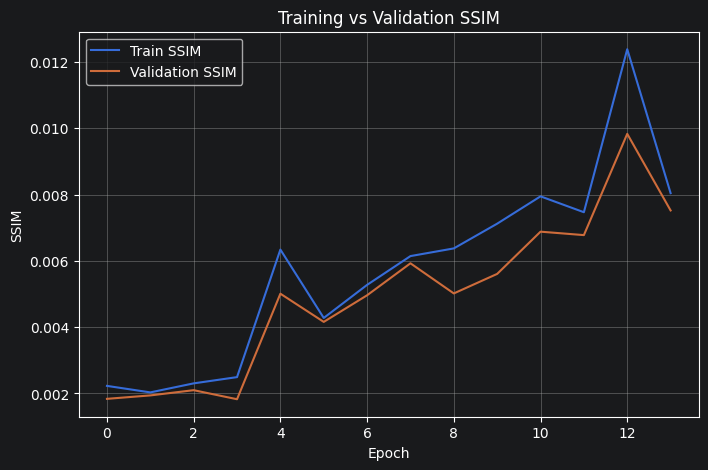

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_ssim"], label="Train SSIM")
plt.plot(history["val_ssim"], label="Validation SSIM")
plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.title("Training vs Validation SSIM")
plt.legend()
plt.grid(True)
plt.savefig(f"{CURRENT_RUN_DIRECTORY}/ssim.png", dpi=300, bbox_inches="tight")

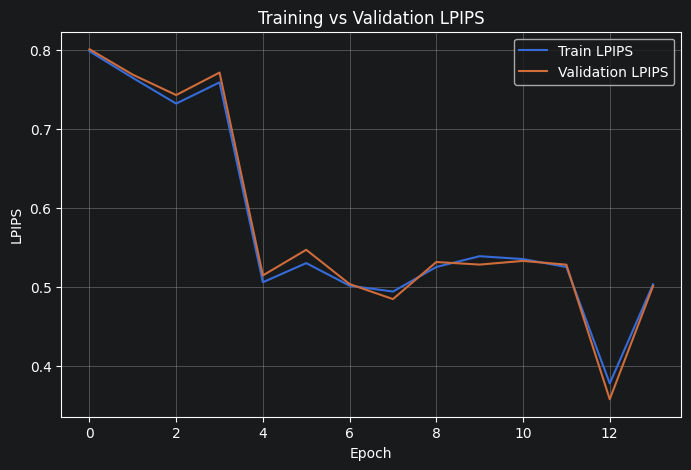

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_lpips"], label="Train LPIPS")
plt.plot(history["val_lpips"], label="Validation LPIPS")
plt.xlabel("Epoch")
plt.ylabel("LPIPS")
plt.title("Training vs Validation LPIPS")
plt.legend()
plt.grid(True)
plt.savefig(f"{CURRENT_RUN_DIRECTORY}/lpips.png", dpi=300, bbox_inches="tight")

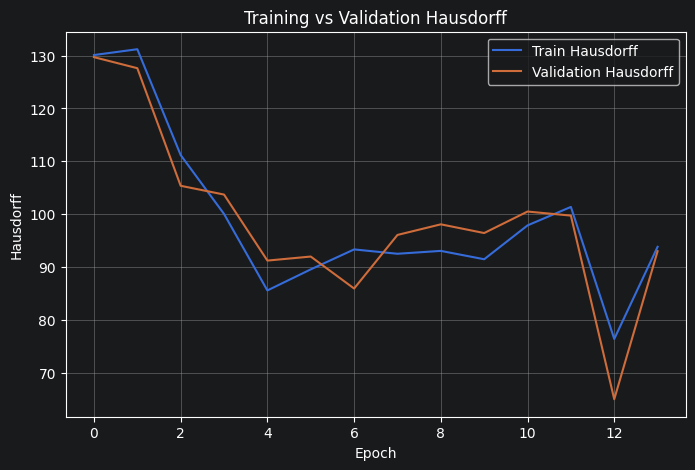

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_hausdorff"], label="Train Hausdorff")
plt.plot(history["val_hausdorff"], label="Validation Hausdorff")
plt.xlabel("Epoch")
plt.ylabel("Hausdorff")
plt.title("Training vs Validation Hausdorff")
plt.legend()
plt.grid(True)
plt.savefig(f"{CURRENT_RUN_DIRECTORY}/hausdorff.png", dpi=300, bbox_inches="tight")

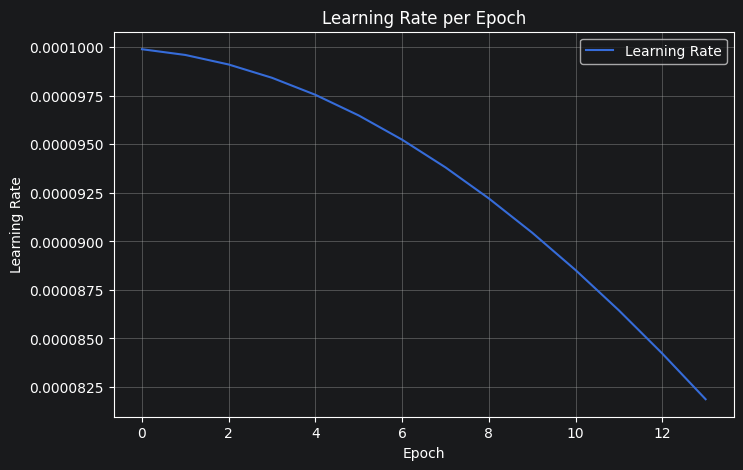

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history["lr"], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate per Epoch")
plt.legend()
plt.grid(True)
plt.savefig(f"{CURRENT_RUN_DIRECTORY}/lr.png", dpi=300, bbox_inches="tight")

# Evaluation

In [22]:
model = UNet(param_dim=PARAMS_DIM, base_ch=UNET_BASE_CHANNELS_NUM).to(device)
model.load_state_dict(torch.load(CURRENT_RUN_DIRECTORY / "best_model.pth"))
model.eval()

UNet(
  (time_emb): Sequential(
    (0): SinusoidalPosEmb()
    (1): Linear(in_features=128, out_features=256, bias=True)
    (2): SiLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
  )
  (cond_emb): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (enc1): ResBlock(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (time_proj): Linear(in_features=128, out_features=64, bias=True)
    (cond_proj): Linear(in_features=128, out_features=64, bias=True)
    (skip): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (enc2): ResBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 128, kernel_si

In [23]:
metrics = compute_metrics(
    model,
    ddpm,
    test_loader,
    device,
    num_samples=TESTING_DATASET_SIZE,
    save_images=True,
    output_dir=CURRENT_RUN_DIRECTORY
)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project3-rendering/venv/lib/python3.14/site-packages/lpips/weights/v0.1/alex.pth


In [24]:
for metric_name, metric_value in metrics.items():
    arrow = "↑ higher is better" if metric_name == "SSIM" else "↓ lower is better"

    print(f"{metric_name}: {metric_value:.4f}           {arrow}")

SSIM: 0.0075           ↑ higher is better
LPIPS: 0.5428           ↓ lower is better
Hausdorff: 100.2729           ↓ lower is better
